In [41]:
from google.colab import files
uploaded = files.upload()

Saving titanic_cleaned.csv to titanic_cleaned (1).csv


In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency
from scipy.stats import ttest_ind

df = pd.read_csv("titanic_cleaned.csv")

df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Unknown,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Unknown,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Unknown,Southampton,no,True


In [43]:
df.shape

(781, 15)

In [44]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
deck           0
embark_town    0
alive          0
alone          0
dtype: int64


In [45]:
print("\nDuplicate Rows:")
print(df.duplicated().sum())


Duplicate Rows:
0


Research Question:

Does passenger gender have a statistically significant relationship
with survival on the Titanic?

Null Hypothesis (H₀):

Gender and survival are independent. There is no statistically
significant association between passenger gender and survival.

Alternative Hypothesis (H₁):

Gender and survival are not independent. There is a statistically
significant association between passenger gender and survival.

Significance Level (α):

0.05

In [46]:
df["survived"].mean()*100

np.float64(41.35723431498079)

In [47]:
print("Overall Survival Rate:")
print(df["survived"].mean() * 100)

Overall Survival Rate:
41.35723431498079


In [48]:
print("\nSurvival by Gender:")
print(df.groupby("sex")["survived"].mean() * 100)


Survival by Gender:
sex
female    74.061433
male      21.721311
Name: survived, dtype: float64


In [49]:
print("\nSurvival Counts by Gender:")
print(pd.crosstab(df["sex"], df["survived"]))


Survival Counts by Gender:
survived    0    1
sex               
female     76  217
male      382  106


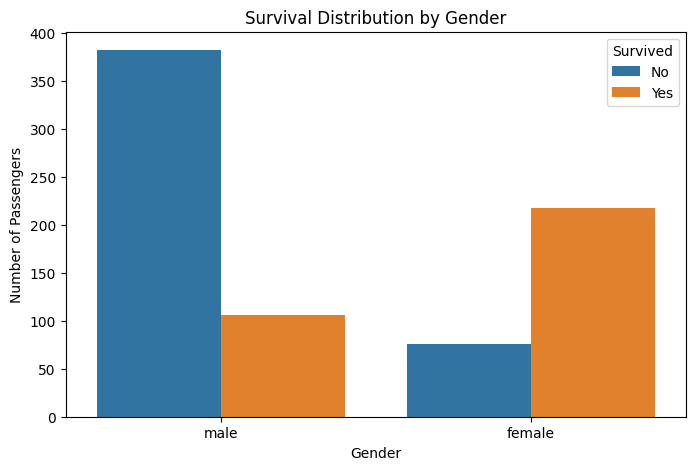

In [50]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="sex", hue="survived")

plt.title("Survival Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")
plt.legend(title="Survived", labels=["No", "Yes"])

plt.show()

The visualization compares survival outcomes between male and female passengers. It provides an initial visual indication that survival was distributed differently across gender groups. This observation motivates the formal Chi-Square test.

In [51]:
contingency_table = pd.crosstab(df["sex"], df["survived"])

chi2, p_value, dof, expected = chi2_contingency(contingency_table)

print("Chi-Square Statistic:", chi2)
print("P-Value:", p_value)
print("Degrees of Freedom:", dof)

print("\nExpected Frequencies:")
print(expected)

Chi-Square Statistic: 204.64249779615164
P-Value: 2.0267093950549394e-46
Degrees of Freedom: 1

Expected Frequencies:
[[171.82330346 121.17669654]
 [286.17669654 201.82330346]]


In [52]:
alpha = 0.05

if p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("There is a statistically significant association between gender and survival.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is not enough evidence of a statistically significant association.")

Reject the Null Hypothesis (H₀)
There is a statistically significant association between gender and survival.


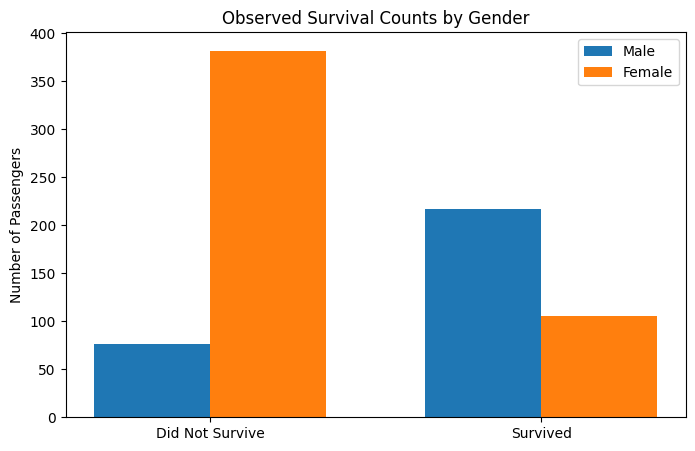

In [53]:
observed = contingency_table.values

x = np.arange(observed.shape[1])
width = 0.35

plt.figure(figsize=(8,5))

plt.bar(
    x - width/2,
    observed[0],
    width,
    label="Male"
)

plt.bar(
    x + width/2,
    observed[1],
    width,
    label="Female"
)

plt.xticks(x, ["Did Not Survive", "Survived"])
plt.ylabel("Number of Passengers")
plt.title("Observed Survival Counts by Gender")
plt.legend()

plt.show()

This visualization presents the observed survival counts used in the Chi-Square analysis. It makes the categorical differences visible before interpreting the statistical test.

Research Question:
Is the average age significantly different between passengers
who survived and passengers who did not survive?

H₀:
The mean age of survivors and non-survivors is equal.

H₁:
The mean age of survivors and non-survivors is different.

In [54]:
survived_age = df[df["survived"] == 1]["age"]
not_survived_age = df[df["survived"] == 0]["age"]

print("Mean age of survivors:", survived_age.mean())
print("Mean age of non-survivors:", not_survived_age.mean())

Mean age of survivors: 28.321733746130032
Mean age of non-survivors: 30.540393013100438


In [55]:
t_stat, t_p_value = ttest_ind(
    survived_age,
    not_survived_age,
    equal_var=False
)

print("T-Statistic:", t_stat)
print("P-Value:", t_p_value)

T-Statistic: -2.209834691249718
P-Value: 0.027450359324870985


In [56]:
alpha = 0.05

if t_p_value < alpha:
    print("Reject the Null Hypothesis (H₀)")
    print("The mean ages are statistically significantly different.")
else:
    print("Fail to Reject the Null Hypothesis (H₀)")
    print("There is not enough evidence that the mean ages are different.")

Reject the Null Hypothesis (H₀)
The mean ages are statistically significantly different.


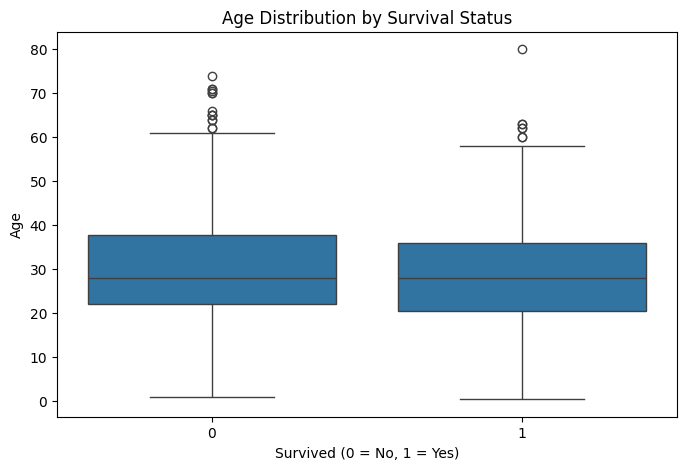

In [57]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="survived", y="age")

plt.title("Age Distribution by Survival Status")
plt.xlabel("Survived (0 = No, 1 = Yes)")
plt.ylabel("Age")

plt.show()

The box plot compares the age distributions of survivors and non-survivors. It shows the median, spread, and potential outliers, providing visual support for the independent t-test.

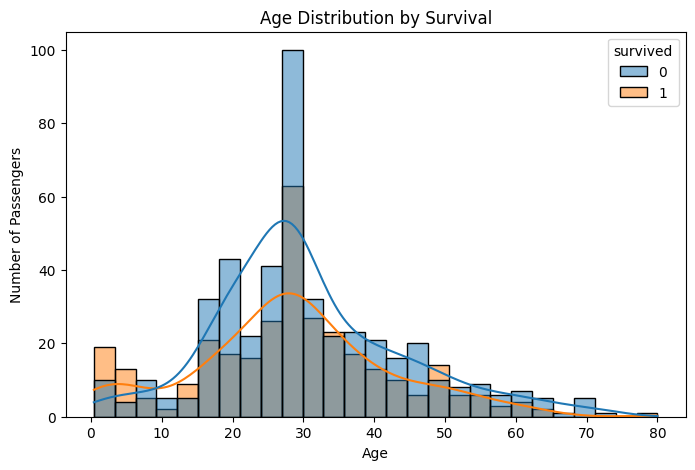

In [58]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="age",
    hue="survived",
    kde=True
)

plt.title("Age Distribution by Survival")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

The histogram provides a detailed view of how passenger ages are distributed across the two survival groups. It complements the box plot by showing the shape of the distributions.

In [59]:
from scipy.stats import t

mean1 = survived_age.mean()
mean2 = not_survived_age.mean()

n1 = survived_age.count()
n2 = not_survived_age.count()

var1 = survived_age.var()
var2 = not_survived_age.var()

mean_diff = mean1 - mean2

se = np.sqrt((var1/n1) + (var2/n2))

df_welch = ((var1/n1 + var2/n2)**2) / (
    ((var1/n1)**2)/(n1-1) +
    ((var2/n2)**2)/(n2-1)
)

critical_value = t.ppf(0.975, df_welch)

lower = mean_diff - critical_value * se
upper = mean_diff + critical_value * se

print("Mean Difference:", mean_diff)
print("95% Confidence Interval:", lower, "to", upper)

Mean Difference: -2.2186592669704055
95% Confidence Interval: -4.189972807627726 to -0.24734572631308516


A 95% confidence interval was calculated for the difference between the mean ages of survivors and non-survivors. The interval provides a range of plausible values for the population-level difference in mean age.